
===== Multi-Horizon Results =====
h=1h | Train RMSE=0.617 | Val RMSE=0.654 | Val MAE=0.475 | Baseline RMSE=0.811 | Improvement=19.3%
h=6h | Train RMSE=2.344 | Val RMSE=3.197 | Val MAE=2.520 | Baseline RMSE=3.499 | Improvement=8.6%
h=12h | Train RMSE=3.089 | Val RMSE=4.982 | Val MAE=3.934 | Baseline RMSE=5.567 | Improvement=10.5%
h=24h | Train RMSE=3.632 | Val RMSE=6.012 | Val MAE=4.778 | Baseline RMSE=7.563 | Improvement=20.5%


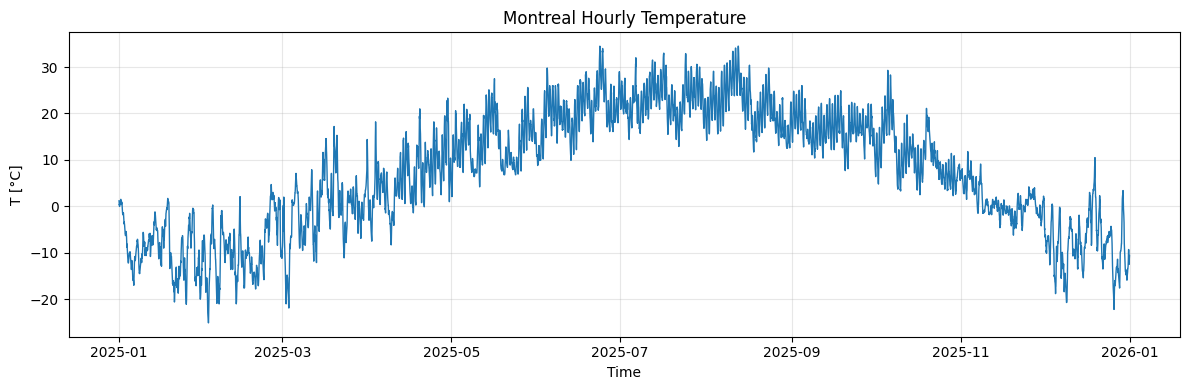

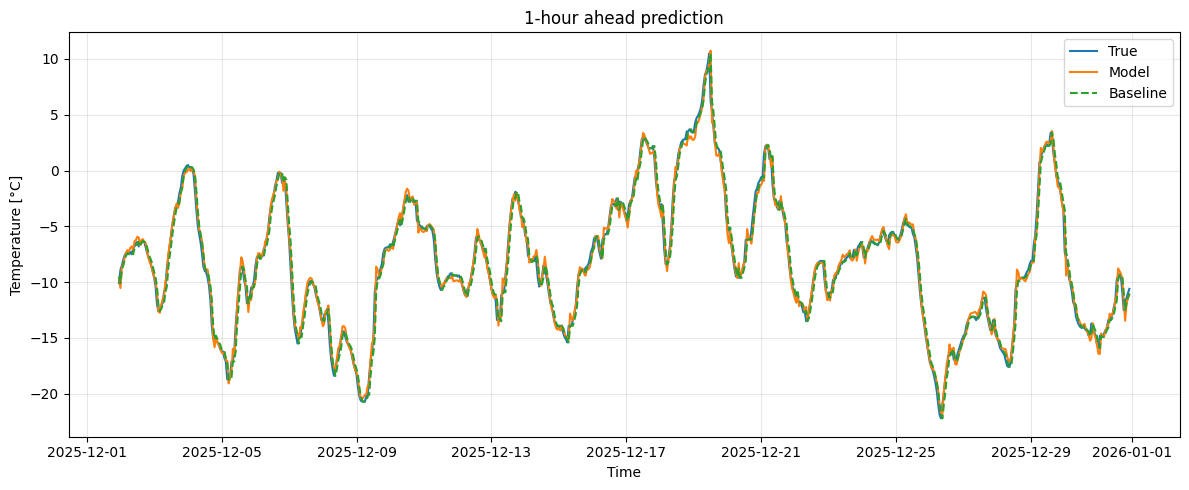

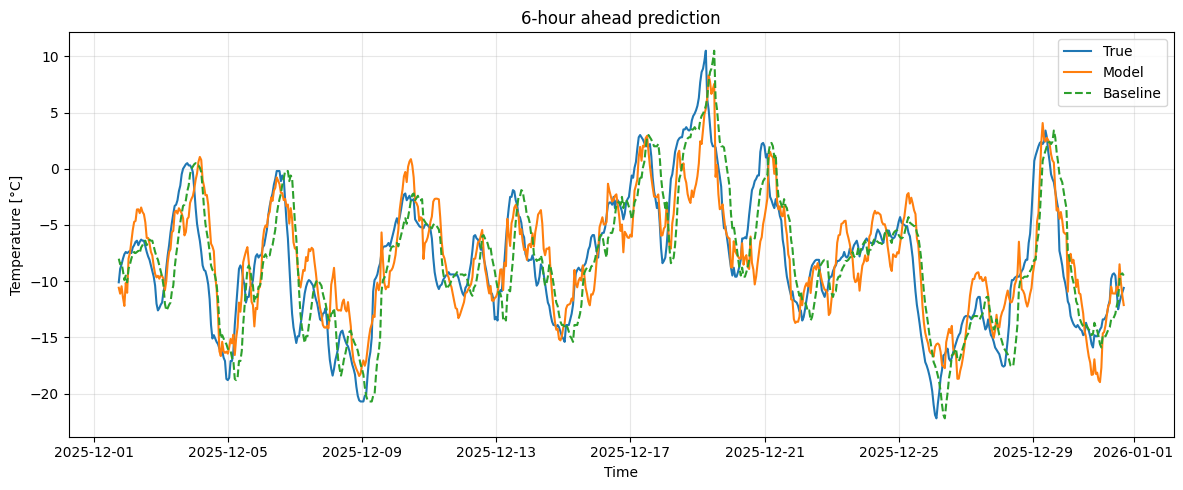

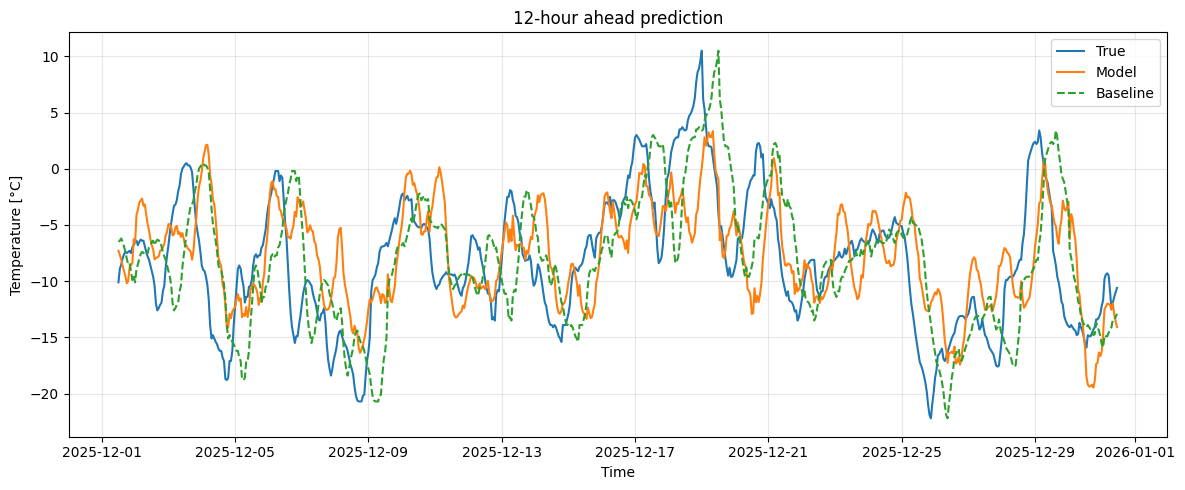

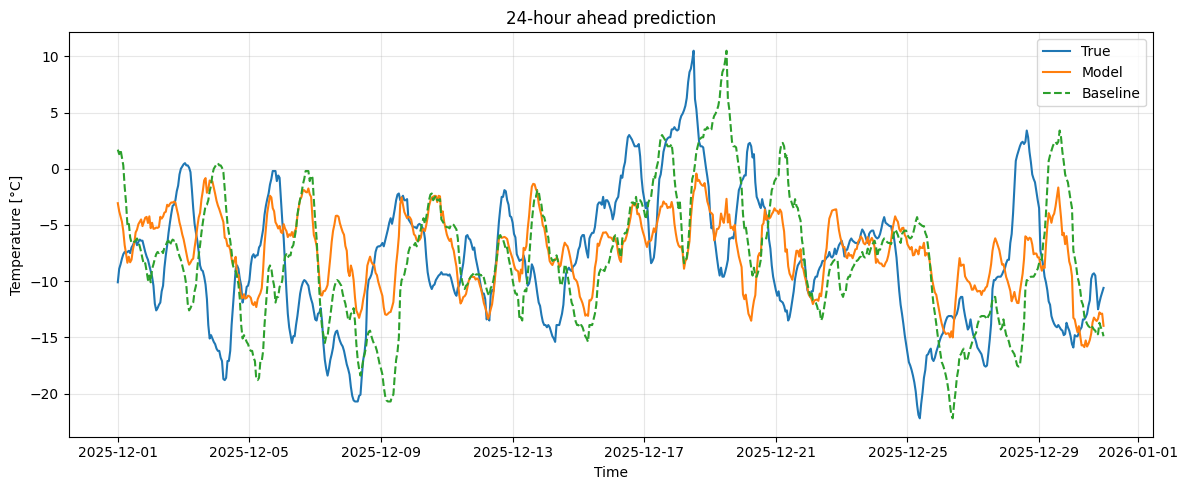


===== Coefficients for 24-hour model =====
  feature  coefficient
intercept     6.600321
        T     0.756733
        W    -0.216925
  sin_day    -1.262391
  cos_day    -0.096763
 sin_year    -2.291408
 cos_year    -7.570217
   T_lag1    -0.120294
   T_lag2    -0.002192
   T_lag3    -0.020624
   T_lag6    -0.090730
  T_lag12    -0.040806
  T_lag24    -0.020353
  T_lag48     0.028128
   W_lag1     0.019097
   W_lag2    -0.019375
   W_lag6    -0.034734
  W_lag12    -0.021894
  W_lag24     0.020103
  W_lag48    -0.015505


In [1]:
# ================================
# MECH 309 - Part 1
# Multi-horizon temperature prediction (1h, 6h, 12h, 24h)
# Updated version:
# - adds 48-hour lag features
# - uses 30-day validation window
# ================================

!pip -q install numpy pandas matplotlib requests

from __future__ import annotations
import math
from dataclasses import dataclass
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# Location definition
# -------------------------------
@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# -------------------------------
# Fetch hourly weather data
# -------------------------------
def fetch_open_meteo_hourly(start_date, end_date, location=MONTREAL):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,wind_speed_10m",
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"] = hourly["temperature_2m"]
    df["W"] = hourly["wind_speed_10m"]

    df.index.name = "time_local"
    return df


# -------------------------------
# Preprocessing + feature construction
# -------------------------------
def preprocess(df):

    # enforce ordered, unique timestamps
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    # enforce continuous hourly grid
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
    df = df.reindex(full_idx)

    # fill missing values
    df = df.interpolate(limit=6).ffill().bfill()

    # daily periodic features
    hour = df.index.hour.to_numpy()
    omega_day = 2 * math.pi / 24
    df["sin_day"] = np.sin(omega_day * hour)
    df["cos_day"] = np.cos(omega_day * hour)

    # seasonal periodic features
    doy = df.index.dayofyear.to_numpy()
    omega_year = 2 * math.pi / 365.25
    df["sin_year"] = np.sin(omega_year * doy)
    df["cos_year"] = np.cos(omega_year * doy)

    return df


# -------------------------------
# Lagged predictors (autoregressive features)
# -------------------------------
def add_lags(df, col, lags):
    for L in lags:
        if L > 0:
            df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# -------------------------------
# Time-based train/validation split
# -------------------------------
def split_train_val(data, val_hours):
    return data.iloc[:-val_hours].copy(), data.iloc[-val_hours:].copy()


# -------------------------------
# Error metrics
# -------------------------------
def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat)**2))


def mae(y, yhat):
    return np.mean(np.abs(y - yhat))


# -------------------------------
# Train + evaluate one horizon
# -------------------------------
def run_model(df_base, h, feature_cols, val_hours=24*30):

    # define target: T(k+h)
    df = df_base.copy()
    df["T_target"] = df["T"].shift(-h)

    # remove invalid rows created by lagging and shifting
    df = df.dropna().copy()

    # split into train / validation
    train_df, val_df = split_train_val(df, val_hours)

    # build regression matrices
    X_train = train_df[feature_cols].to_numpy()
    y_train = train_df["T_target"].to_numpy()

    X_val = val_df[feature_cols].to_numpy()
    y_val = val_df["T_target"].to_numpy()

    # add intercept term
    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val   = np.column_stack([np.ones(len(X_val)), X_val])

    # solve least squares: min ||Xθ - y||²
    theta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    # predictions
    yhat_train = X_train @ theta
    yhat_val = X_val @ theta

    # baseline: persistence T(k+h) ≈ T(k)
    baseline = val_df["T"].to_numpy()

    return {
        "h": h,
        "rmse_model": rmse(y_val, yhat_val),
        "rmse_baseline": rmse(y_val, baseline),
        "mae_model": mae(y_val, yhat_val),
        "mae_baseline": mae(y_val, baseline),
        "train_rmse": rmse(y_train, yhat_train),
        "val_index": val_df.index,
        "y_val": y_val,
        "yhat": yhat_val,
        "baseline": baseline,
        "theta": theta
    }


# ================================
# MAIN PIPELINE
# ================================

# 1) Data acquisition
df_raw = fetch_open_meteo_hourly("2025-01-01", "2025-12-31")

# 2) Preprocessing + feature engineering
df = preprocess(df_raw)

# 3) Add autoregressive predictors
df = add_lags(df, "T", [1, 2, 3, 6, 12, 24, 48])
df = add_lags(df, "W", [1, 2, 6, 12, 24, 48])

# 4) Feature set
feature_cols = [
    "T", "W",
    "sin_day", "cos_day",
    "sin_year", "cos_year",
    "T_lag1", "T_lag2", "T_lag3", "T_lag6", "T_lag12", "T_lag24", "T_lag48",
    "W_lag1", "W_lag2", "W_lag6", "W_lag12", "W_lag24", "W_lag48",
]

# 5) Horizons to evaluate
horizons = [1, 6, 12, 24]

results = []

# 6) Train model for each horizon
for h in horizons:
    res = run_model(df, h, feature_cols, val_hours=24*30)
    results.append(res)

# -------------------------------
# 7) Print summary table
# -------------------------------
print("\n===== Multi-Horizon Results =====")
for r in results:
    improvement = 100 * (r["rmse_baseline"] - r["rmse_model"]) / r["rmse_baseline"]
    print(
        f"h={r['h']}h | "
        f"Train RMSE={r['train_rmse']:.3f} | "
        f"Val RMSE={r['rmse_model']:.3f} | "
        f"Val MAE={r['mae_model']:.3f} | "
        f"Baseline RMSE={r['rmse_baseline']:.3f} | "
        f"Improvement={improvement:.1f}%"
    )

# -------------------------------
# 8) Plot full temperature signal
# -------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["T"], linewidth=1)
plt.title("Montreal Hourly Temperature")
plt.ylabel("T [°C]")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# 9) Plot predictions per horizon
# -------------------------------
for r in results:
    plt.figure(figsize=(12, 5))
    plt.plot(r["val_index"], r["y_val"], label="True")
    plt.plot(r["val_index"], r["yhat"], label="Model")
    plt.plot(r["val_index"], r["baseline"], "--", label="Baseline")
    plt.title(f"{r['h']}-hour ahead prediction")
    plt.ylabel("Temperature [°C]")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 10) Coefficients for 24-hour model
# -------------------------------
res24 = [r for r in results if r["h"] == 24][0]

coef_names = ["intercept"] + feature_cols
coef_table = pd.DataFrame({
    "feature": coef_names,
    "coefficient": res24["theta"]
})

print("\n===== Coefficients for 24-hour model =====")
print(coef_table.to_string(index=False))